In [39]:
#START - GETTING STARTED WITH EXPLORATION

# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Always show plots inline
%matplotlib inline

# --- Path sanity check ---
print("Notebook running from:", Path.cwd())

# Define project paths
ROOT = Path("..").resolve()   # one level up from 'notebooks' → 'BBO'
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("DATA:", DATA)

# List subfolders/files inside data
print("Contents of DATA:")
for p in sorted(DATA.iterdir()):
    print("   ", p.name)

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA:
    F1
    F2
    F3
    F4
    F5
    F6
    F7
    F8
    function_summary.csv


In [40]:
#DATA LOADING SECTION
# --- Select which function to inspect ---
FN = "F1"   # change to F2..F8 as needed
print(f"Loading data for {FN}")

# --- Read function description ---
summary_path = DATA / "function_summary.csv"
func_info = pd.read_csv(summary_path)

if "Function" in func_info.columns and "Description" in func_info.columns:
    desc_row = func_info.loc[func_info["Function"] == FN, "Description"]
    if not desc_row.empty:
        print(f"\n{FN} description:\n{desc_row.values[0]}")
    else:
        print(f"No description found for {FN} in function_summary.csv.")
else:
    print("⚠️ function_summary.csv missing expected columns.")

# --- Load inputs/outputs ---
X_path = DATA / FN / "initial_inputs.npy"
y_path = DATA / FN / "initial_outputs.npy"

X = np.load(X_path)
y = np.load(y_path)

# --- Build DataFrame for exploration ---
cols = [f"x{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)
df["y"] = y

# --- Show quick look ---
display(df.head())
display(df.describe())

# --- Summary dictionary ---
summary = {
    "rows": len(df),
    "dims": X.shape[1],
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in cols},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
print("\nSummary of loaded data:")
summary



Loading data for F1

F1 description:
Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03


,x1,x2,y
count,11.000000,11.000000,1.100000e+01
mean,0.544530,0.536268,-3.278238e-04
std,0.246272,0.281024,1.087269e-03
min,0.082507,0.078723,-3.606063e-03
25%,0.364921,0.334110,-1.044547e-91
50%,0.574329,0.582254,1.322677e-79
75%,0.707221,0.747980,1.267501e-40
max,0.883890,0.879898,6.582525e-10



Summary of loaded data:


{'rows': 11,
 'dims': 2,
 'bounds': {'x1': (0.08250725182080587, 0.8838898288181171),
  'x2': (0.07872277794971883, 0.879898104984359)},
 'y_min': -0.0036060626443634764,
 'y_max': 6.58252487183483e-10}

In [41]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


F1 has 2 input dimensions


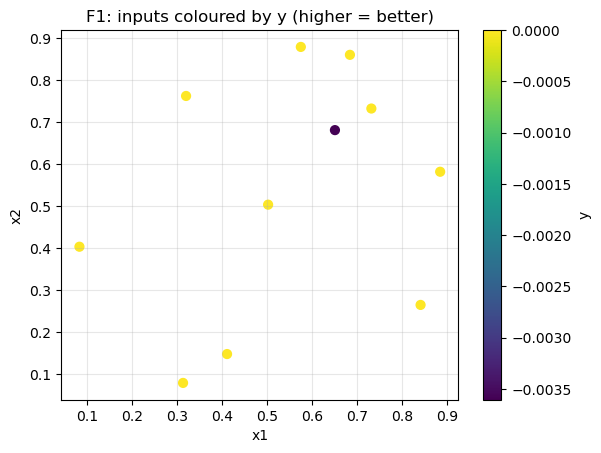

In [42]:
#INITIAL PLOTS TO VISUALISE THE DATA

# --- Quick visual exploration of inputs and outputs ---
import seaborn as sns

xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

print(f"{FN} has {d} input dimensions")

sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"], cmap="viridis", s=40)
plt.xlabel(xs[0]); plt.ylabel(xs[1])
plt.title(f"{FN}: inputs coloured by y (higher = better)")
plt.colorbar(sc, label="y")
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
# === Fit a small, sturdy GP (minimization) ===
kernel = C(1.0, (1e-6, 1e6)) * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-3, 1e5), nu=2.5) \
         + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-3))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gp.fit(X, y)

# === Candidates: dense grid on [0,1]^2 (fast in 2D) ===
g = np.linspace(0.0, 1.0, 201)
G = np.array(np.meshgrid(g, g)).reshape(2, -1).T  # (201*201, 2)

# === EI for MINIMIZATION ===
mu, sd = gp.predict(G, return_std=True)
sd = sd.reshape(-1)
y_best = np.min(y)
imp = (y_best - mu)
Z = np.zeros_like(imp)
nz = sd > 1e-12
Z[nz] = imp[nz] / sd[nz]
EI = np.zeros_like(imp)
EI[nz] = imp[nz]*norm.cdf(Z[nz]) + sd[nz]*norm.pdf(Z[nz])

pick = np.argmax(EI)
x_next = G[pick]

# === FINAL OUTPUT: RECOMMENDED NEXT POINT TO SUBMIT ===
print("\n" + "="*70)
print("F1 — RECOMMENDED NEXT POINT")
print("="*70)
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI: predicted mean={mu[pick]:.6f}, std={sd[pick]:.6f}, EI={EI[pick]:.6e}")

x_next_df = pd.DataFrame([x_next], columns=["x1","x2"]).round(6)
display(x_next_df.style.set_caption("🚀 Submit this point"))
print("="*70)
print("Copy these values into the portal.")
print("="*70)


F1 — RECOMMENDED NEXT POINT
Best y so far: -0.003606
Chosen by EI: predicted mean=-0.003391, std=0.000397, EI=7.356716e-05


,x1,x2
0,0.645000,0.670000


Copy these values into the portal.
